# Estimating Difficulty with actual human responses from OneStopQA / RACE Prolific Experiments

Investigates whether we can get a genuine, model-independent **per-question difficulty ground truth** from real human responses, as an alternative to attention-entropy-based signals (which `entropy_manual_review.ipynb` found to be unreliable -- dominated by attention-sink artifacts, inconsistent across metrics/granularities/heads, and theoretically limited by "attention is not explanation").

Data source: https://github.com/berzak/onestop-qa (cloned as a sibling repo, `../../../onestop-qa` relative to this notebook) -- `human_experiments/prolific/qa.tsv`, 972 Prolific participants each answering 4 real items (2 OneStopQA + 2 RACE-ish mix, 648 of each across all participants) + 2 practice items.

## Contents

0. [Imports and paths](#imports)
1. [Load data](#load)
2. [Inspect data](#view-samples)
3. [Resolve correct answers](#resolve)
4. [Accuracy by participant demographics (age, education)](#demographics)
5. [Per-item human accuracy](#per-item-accuracy)
6. [Sanity check vs. the difficulty tag](#sanity-check)
7. [IRT (Rasch model) fitting](#irt)
8. [Bayesian 3PL IRT (posterior uncertainty)](#bayesian-irt)


<a id="imports"></a>
## 0. Imports and paths

In [41]:
import sys, random, json
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ONESTOPQA_REPO = Path("../../../onestop-qa").resolve()
QA_TSV = ONESTOPQA_REPO / "human_experiments/prolific/qa.tsv"
ONESTOP_QA_ZIP = ONESTOPQA_REPO / "annotations/onestop_qa.zip"
assert QA_TSV.exists(), f"not found: {QA_TSV} -- clone berzak/onestop-qa as a sibling of this repo"
assert ONESTOP_QA_ZIP.exists(), f"not found: {ONESTOP_QA_ZIP}"

sys.path.insert(0, str(Path.cwd().resolve().parents[1]))  # reading-question-generator root
from question_difficulty.methods.human_answer_based.irt.data_processing import HumanResponseBank
from question_difficulty.methods.human_answer_based.irt.rasch_model import fit_rasch

<a id="load"></a>
## 1. Load data

In [42]:
bank = HumanResponseBank(ONESTOPQA_REPO)
ALL_ROWS = bank.rows

df = pd.DataFrame(ALL_ROWS)
print(df.shape)
print(df.columns.tolist())
df.head()

(3880, 25)
['QUD', 'RT', 'age', 'item_id', 'comments', 'cumulative_score', 'difficulty', 'education', 'endTime', 'answer_response', 'gender', 'languages', 'new_options', 'options', 'paragraph', 'question', 'source', 'startDate', 'startTime', 'timeSpent', 'trial_number', 'trial_type', 'submission_ind', 'correct_answer_text', 'is_correct']


,QUD,RT,age,item_id,comments,cumulative_score,difficulty,education,endTime,answer_response,...,question,source,startDate,startTime,timeSpent,trial_number,trial_type,submission_ind,correct_answer_text,is_correct
0,Question 3/6,40490,20.0,r1609_3_Middle,,2,Middle,Graduated High School,1571234704013.0,3,...,"If you want to use energy free, you have to ...",RACE,Wed Oct 16 2019 15:02:31 GMT+0100 (British Sum...,1571234551781,2.5372,1,reading_comprehension,1,keep the roof unchanged for within 25 years,False
1,Question 4/6,22038,20.0,os11_6_3_Ele,,2,Ele,Graduated High School,1571234704013.0,0,...,What is one thing Hannah must do when eating a...,Onestop,Wed Oct 16 2019 15:02:31 GMT+0100 (British Sum...,1571234551781,2.5372,2,reading_comprehension,1,Commit specifics of the experience to memory,True
2,Question 5/6,15944,20.0,os10_1_1_Adv,,3,Adv,Graduated High School,1571234704013.0,0,...,What event dramatically reduced the quality of...,Onestop,Wed Oct 16 2019 15:02:31 GMT+0100 (British Sum...,1571234551781,2.5372,3,reading_comprehension,1,The financial crisis that occurred in the country,True
3,Question 6/6,16595,20.0,r13414_3_High,,4,High,Graduated High School,1571234704013.0,0,...,What is the passage mainly about?,RACE,Wed Oct 16 2019 15:02:31 GMT+0100 (British Sum...,1571234551781,2.5372,4,reading_comprehension,1,The general information of the prom.,False
4,Question 3/6,26219,29.0,os17_4_1_Adv,,2,Adv,Graduated College,1571234861122.0,0,...,What is the quote 'I am broke. Things are hard...,Onestop,Wed Oct 16 2019 07:03:40 GMT-0700 (PDT),1571234620397,4.012083333333333,1,reading_comprehension,2,An acceptable thing to say in society,True


In [43]:
by_source = Counter(r["source"] for r in ALL_ROWS)
by_difficulty = Counter(r["difficulty"] for r in ALL_ROWS)
responses_per_item = Counter(len(rows) for rows in bank.rows_by_item().values())
questions_per_participant = Counter(Counter(r["startTime"] for r in ALL_ROWS).values())

print(f"Number of individual human responses:        {len(ALL_ROWS)}")
print(f"Number of distinct passage-question pairs:   {len(set(r['item_id'] for r in ALL_ROWS))}")
print(f"Number of participants:                      {len(set(r['startTime'] for r in ALL_ROWS))}")
print(f"Responses by source:                         {dict(by_source)}")
print(f"Responses by difficulty:                     {dict(by_difficulty)}")
print(f"Responses per question:                      {dict(sorted(responses_per_item.items()))}")
print(f"Questions answered per participant:          {dict(sorted(questions_per_participant.items()))}")

# Is the person-item network ONE connected component (so all item difficulties
# are on a truly comparable scale), or does it split into disconnected clusters?
parent = {}
def find(x):
    while parent[x] != x:
        x = parent[x]
    return x
def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[ra] = rb

nodes = set()
for r in ALL_ROWS:
    nodes.add(("person", r["startTime"]))
    nodes.add(("item", r["item_id"]))
for n in nodes:
    parent.setdefault(n, n)
for r in ALL_ROWS:
    union(("person", r["startTime"]), ("item", r["item_id"]))

components = Counter(find(n) for n in nodes)
largest = max(components.values())
print(f"\nNumber of connected components:              {len(components)}")
print(f"Largest component covers:                    {largest} / {len(nodes)} nodes ({largest/len(nodes):.1%})")
if len(components) > 1:
    print(f"Component size distribution (top 5):          {components.most_common(5)}")

Number of individual human responses:        3880
Number of distinct passage-question pairs:   1296
Number of participants:                      970
Responses by source:                         {'RACE': 1940, 'Onestop': 1940}
Responses by difficulty:                     {'Middle': 970, 'Ele': 970, 'Adv': 970, 'High': 970}
Responses per question:                      {2: 8, 3: 1288}
Questions answered per participant:          {4: 970}

Number of connected components:              324
Largest component covers:                    7 / 2266 nodes (0.3%)
Component size distribution (top 5):          [(('item', 'r644_2_Middle'), 7), (('item', 'r24234_3_High'), 7), (('item', 'r4761_1_High'), 7), (('item', 'r6703_1_Middle'), 7), (('item', 'os6_2_3_Adv'), 7)]


<a id="view-samples"></a>
## 2. Inspect data

In [44]:
from question_difficulty.methods.human_answer_based.irt.data_processing import _texts_match

def view_samples(n=3, source=None, difficulty=None, seed=0):
    """Randomly samples n QA ITEMS (one passage+question per item, deduped
    across the 2-3 participants who each answered it -- not response rows)
    and prints the passage, question, options (marking the correct one),
    and each participant's raw answer_response with a correct/wrong
    indicator. Optionally filter by source ("RACE"/"Onestop") and/or
    difficulty ("Middle"/"High"/"Ele"/"Adv")."""
    pool = ALL_ROWS
    if source is not None:
        pool = [r for r in pool if r["source"] == source]
    if difficulty is not None:
        pool = [r for r in pool if r["difficulty"] == difficulty]

    by_item = defaultdict(list)
    for r in pool:
        by_item[r["item_id"]].append(r)
    item_ids = list(by_item.keys())
    random.Random(seed).shuffle(item_ids)

    for item_id in item_ids[:n]:
        group = by_item[item_id]
        r0 = group[0]
        options = r0["options"].split("|")
        correct_text = r0["correct_answer_text"]
        print("=" * 80)
        print(f"item_id: {item_id}   source: {r0['source']}   difficulty: {r0['difficulty']}")
        print(f"\nPassage:\n{r0['paragraph']}")
        print(f"\nQuestion: {r0['question']}")
        for i, opt in enumerate(options):
            is_correct_opt = correct_text is not None and _texts_match(opt, correct_text)
            print(f"  [{i}] {opt}" + ("  <- correct" if is_correct_opt else ""))
        print(f"\n{len(group)} participant response(s):")
        for r in group:
            mark = "n/a (unresolved)" if r["is_correct"] is None else ("correct" if r["is_correct"] else "wrong")
            print(f"  answer_response={r['answer_response']}  [{mark}]  (RT={r['RT']}ms, timeSpent={r['timeSpent']}s)")
    print("=" * 80)


view_samples(n=2)

item_id: r1711_3_Middle   source: RACE   difficulty: Middle

Passage:
Are you carrying too much on your back at school? You're not alone. Back experts  in the USA are worried about that young students are having back and neck problems because they are carrying too much in their backpacks .\n"It hurts my back when I run," said Ebelin Reyes, a student in Virginia. "It's hard to get up the stairs with my backpack because it's too heavy." Students have to carry heavy backpacks on their backs for a whole week's study. Ebelin is one of them. They have   regular backpacks with two straps  to carry them, but a number of students with heavy loads  have _ rolling backpacks. The backpacks have wheels and can roll on the ground. Shirley Park's backpack weighs 10 kilos, and she said, "I'll change to a rolling backpack because I am starting to have back pain."\nHow much is too much? Experts say that students should carry no more than 10% to 15% of their own body weight. A few students have had a goo

<a id="resolve"></a>
## 3. Resolve correct answers

`qa.tsv` has no correct-answer column, so we cross-reference each item back to its source dataset. All of this happens automatically inside `HumanResponseBank` (built in §1):

- Logic lives in `question_difficulty/methods/human_answer_based/irt/data_processing.py`
- Maps OneStopQA `item_id`s to their source article/paragraph/question
- Matches RACE questions back to `ehovy/race`
- Uses `answer_response` as a **direct index into `options`** (verified empirically — this gives plausible ~76-81% accuracy; the alternative gives ~25-28%, i.e. chance)
- Result: every row in `ALL_ROWS` (`== bank.rows`) already has `correct_answer_text` and `is_correct` attached

In [45]:
n_resolved = sum(1 for r in ALL_ROWS if r["is_correct"] is not None)
n_correct = sum(1 for r in ALL_ROWS if r["is_correct"])
print(f"resolved: {n_resolved}, unresolved: {len(ALL_ROWS) - n_resolved} (of {len(ALL_ROWS)} total rows)")
print(f"overall accuracy (resolved rows only): {n_correct/n_resolved:.1%}")

resolved: 3880, unresolved: 0 (of 3880 total rows)
overall accuracy (resolved rows only): 76.0%


<a id="demographics"></a>
## 4. Accuracy by participant demographics (age, education)

Checks whether age/education predict raw per-person accuracy. This is a simple demographic breakdown, NOT an IRT ability estimate -- it sidesteps the disconnected-cluster problem found in §7, since we're only averaging each person's own scores, not comparing item difficulties across people. Caveat: `n_persons` per cell will be small (~970 people split across ~5 age buckets x 4 education levels), so treat this as suggestive, not definitive.


age_group             education  n_persons  mean_accuracy
    18-24     Graduated College         70       0.746429
    18-24 Graduated High School         89       0.735955
    18-24         Higher Degree         34       0.757353
    18-24               Unknown          2       0.875000
    25-34     Graduated College        161       0.750000
    25-34 Graduated High School         58       0.715517
    25-34         Higher Degree        111       0.734234
    25-34               Unknown          4       0.812500
    35-44     Graduated College         80       0.803125
    35-44 Graduated High School         47       0.734043
    35-44         Higher Degree         57       0.789474
    35-44               Unknown          5       0.800000
    45-54     Graduated College         45       0.811111
    45-54 Graduated High School         34       0.764706
    45-54         Higher Degree         31       0.846774
    45-54               Unknown          4       0.875000
      55+     

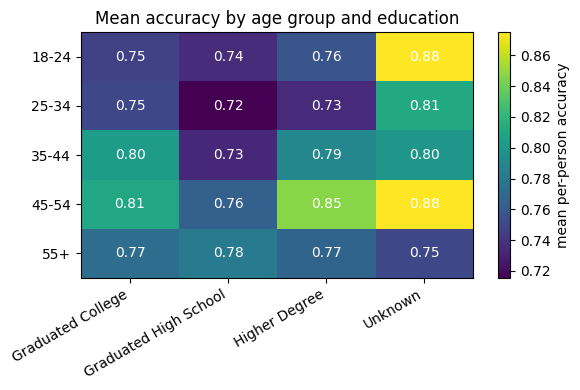

In [46]:
df = pd.DataFrame(ALL_ROWS)
person_df = (
    df.groupby("startTime")
    .agg(age=("age", "first"), education=("education", "first"),
         accuracy=("is_correct", "mean"), n_answered=("is_correct", "count"))
    .reset_index()
)
person_df["age"] = pd.to_numeric(person_df["age"], errors="coerce")
person_df["education"] = person_df["education"].replace("", "Unknown")

age_bins = [18, 25, 35, 45, 55, 76]
age_labels = ["18-24", "25-34", "35-44", "45-54", "55+"]
person_df["age_group"] = pd.cut(person_df["age"], bins=age_bins, labels=age_labels, right=False)

summary = (
    person_df.groupby(["age_group", "education"], observed=False)
    .agg(n_persons=("startTime", "count"), mean_accuracy=("accuracy", "mean"))
    .reset_index()
)
print(summary.to_string(index=False))

pivot = summary.pivot(index="age_group", columns="education", values="mean_accuracy")
plt.figure(figsize=(6, 4))
plt.imshow(pivot.values, aspect="auto", cmap="viridis")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=30, ha="right")
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label="mean per-person accuracy")
plt.title("Mean accuracy by age group and education")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if pd.notna(val):
            plt.text(j, i, f"{val:.2f}", ha="center", va="center", color="white")
plt.tight_layout()
plt.show()

# Simulated-student bucket key per person -- reused by §7/§8's IRT fit.
person_bucket = dict(zip(person_df["startTime"],
                          person_df["age_group"].astype(str) + "|" + person_df["education"]))


<a id="per-item-accuracy"></a>
## 5. Per-item human accuracy

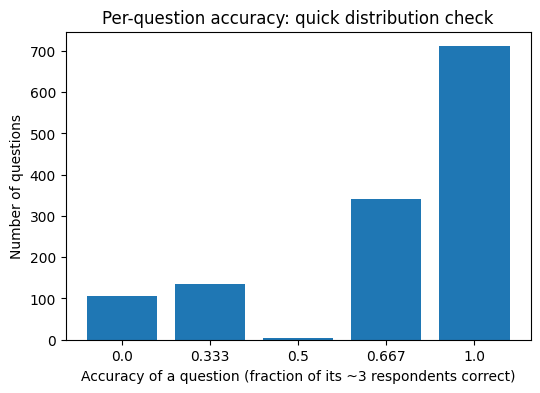

In [47]:
from collections import Counter

item_accuracy = bank.item_accuracy()
acc_counts = Counter(round(v, 3) for v in item_accuracy.values())

plt.figure(figsize=(6, 4))
values = sorted(acc_counts)
plt.bar([str(v) for v in values], [acc_counts[v] for v in values])
plt.xlabel("Accuracy of a question (fraction of its ~3 respondents correct)")
plt.ylabel("Number of questions")
plt.title("Per-question accuracy: quick distribution check")
plt.show()

<a id="sanity-check"></a>
## 6. Sanity check vs. the difficulty tag

In [48]:
item_meta = bank.item_metadata()

groups = defaultdict(list)
for item_id, acc in item_accuracy.items():
    source, difficulty = item_meta[item_id]
    groups[(source, difficulty)].append(acc)

print(f"{'source':10s} {'difficulty':10s} {'n_items':>8s} {'mean_acc':>9s}")
for (source, difficulty), accs in sorted(groups.items()):
    print(f"{source:10s} {difficulty:10s} {len(accs):8d} {sum(accs)/len(accs):9.3f}")

source     difficulty  n_items  mean_acc
Onestop    Adv             324     0.791
Onestop    Ele             324     0.811
RACE       High            324     0.617
RACE       Middle          324     0.820


<a id="irt"></a>
## 7. IRT (Rasch model) fitting

Fits a difficulty score per question and an ability score per person, using the formula `P(correct) = sigmoid(ability - difficulty)`.

**"Person" here means an (age_group, education) demographic bucket from §4, not an individual.** §1's connectivity check found that the individual-level person-item network splits into 324 disconnected 3-person/4-item clusters -- each individual only answers 4 items, so there's no real overlapping evidence to link difficulty estimates across the whole dataset. Bucketing by demographics instead pools many individuals (who each answered *different* items) into one "simulated student" node, which connects the network -- trading individual-level resolution for a properly-linked, dataset-wide difficulty scale.

- Only 1PL (Rasch) -- not 2PL/3PL, since those need more responses per item than we have to estimate reliably.
- Treat these as **rough** estimates, not precise ones.


In [55]:
triples = [(person_bucket[r["startTime"]], r["item_id"], r["is_correct"])
           for r in ALL_ROWS if r["is_correct"] is not None and r["startTime"] in person_bucket]
print(f"{len(triples)} observations, {len(set(t[0] for t in triples))} simulated-student buckets, "
      f"{len(set(t[1] for t in triples))} items")

# Confirm the bucket-item network is actually connected (unlike the
# individual-level one checked in §1) before trusting the fit.
parent = {}
def find(x):
    while parent[x] != x:
        x = parent[x]
    return x
def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[ra] = rb

nodes = set()
for bucket, item_id, _ in triples:
    nodes.add(("bucket", bucket))
    nodes.add(("item", item_id))
for n in nodes:
    parent.setdefault(n, n)
for bucket, item_id, _ in triples:
    union(("bucket", bucket), ("item", item_id))
components = Counter(find(n) for n in nodes)
largest = max(components.values())
print(f"Connected components: {len(components)}  |  largest covers {largest}/{len(nodes)} nodes ({largest/len(nodes):.1%})")

rasch = fit_rasch(triples)
print("converged:", rasch.converged, "| final loss:", rasch.loss)

item_difficulty = rasch.item_difficulty

print("\nSimulated-student ability by bucket (higher = more able):")
for bucket, theta in sorted(rasch.person_ability.items(), key=lambda x: -x[1]):
    print(f"  {bucket:40s} theta={theta:+.3f}")

# Cache the raw triples so §8 (Bayesian IRT, needs a different kernel/env --
# see below) can load them without needing HumanResponseBank/`datasets` there.
TRIPLES_CACHE = Path("irt_triples_cache.json")
json.dump(triples, open(TRIPLES_CACHE, "w"))
print(f"\ncached triples to {TRIPLES_CACHE.resolve()}")

# Also cache the Rasch item difficulties themselves, so §8 can plot the
# distribution side-by-side with the Bayesian posterior means.
RASCH_DIFFICULTY_CACHE = Path("irt_rasch_difficulty_cache.json")
json.dump(item_difficulty, open(RASCH_DIFFICULTY_CACHE, "w"))
print(f"cached Rasch item difficulties to {RASCH_DIFFICULTY_CACHE.resolve()}")

# Also cache per-item raw accuracy (from §5), so §8 can plot Bayesian
# difficulty vs. raw accuracy the same way §7 does for Rasch.
ACCURACY_CACHE = Path("irt_item_accuracy_cache.json")
json.dump(item_accuracy, open(ACCURACY_CACHE, "w"))
print(f"cached item accuracy to {ACCURACY_CACHE.resolve()}")

# Also cache item_meta (source/difficulty tag per item, from §6), so §8 can
# do the same source/level-vs-difficulty sanity check for the Bayesian estimate.
META_CACHE = Path("irt_item_meta_cache.json")
json.dump(item_meta, open(META_CACHE, "w"))
print(f"cached item metadata to {META_CACHE.resolve()}")


3880 observations, 24 simulated-student buckets, 1296 items
Connected components: 1  |  largest covers 1320/1320 nodes (100.0%)
converged: True | final loss: 1372.7782264191396

Simulated-student ability by bucket (higher = more able):
  45-54|Unknown                            theta=+2.241
  18-24|Unknown                            theta=+1.940
  45-54|Higher Degree                      theta=+1.911
  45-54|Graduated College                  theta=+1.812
  55+|Unknown                              theta=+1.802
  35-44|Graduated College                  theta=+1.774
  18-24|Higher Degree                      theta=+1.752
  55+|Graduated College                    theta=+1.698
  nan|Graduated College                    theta=+1.620
  35-44|Higher Degree                      theta=+1.608
  45-54|Graduated High School              theta=+1.552
  18-24|Graduated College                  theta=+1.504
  nan|Graduated High School                theta=+1.490
  25-34|Unknown                     

correlation between IRT difficulty (b) and raw accuracy: -0.992 (expected strongly negative: harder=higher b=lower accuracy)


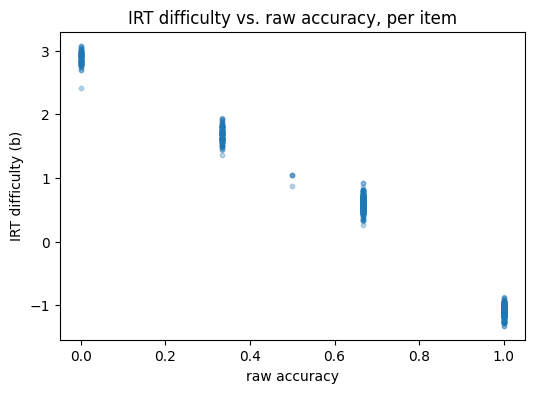

In [50]:
# Compare IRT difficulty (b, higher = harder) against raw accuracy, and against
# the existing passage-level difficulty tag -- does IRT change the picture?
import numpy as np

irt_vals, acc_vals = [], []
for item_id, b in item_difficulty.items():
    if item_id in item_accuracy:
        irt_vals.append(b)
        acc_vals.append(item_accuracy[item_id])
corr = np.corrcoef(irt_vals, acc_vals)[0, 1]
print(f"correlation between IRT difficulty (b) and raw accuracy: {corr:.3f} "
      f"(expected strongly negative: harder=higher b=lower accuracy)")

plt.figure(figsize=(6, 4))
plt.scatter(acc_vals, irt_vals, alpha=0.3, s=10)
plt.xlabel("raw accuracy")
plt.ylabel("IRT difficulty (b)")
plt.title("IRT difficulty vs. raw accuracy, per item")
plt.show()

source     difficulty  n_items   mean_b   std_b
Onestop    Adv             324   -0.139   1.146
Onestop    Ele             324   -0.225   1.115
RACE       High            324    0.543   1.542
RACE       Middle          324   -0.291   1.241


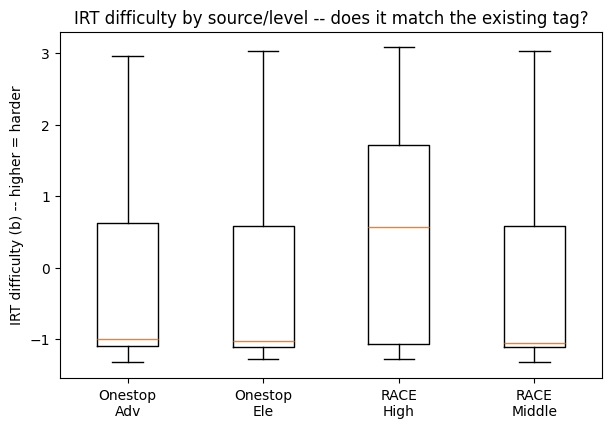

In [51]:
# Does IRT difficulty (b) actually align with the existing passage-level
# difficulty tag (RACE-Middle/High, OneStopQA-Ele/Adv)? Same grouping as
# §6's accuracy table, but for the IRT estimate -- a sanity check that the
# IRT fit is picking up a real signal, not just noise.
irt_groups = defaultdict(list)
for item_id, b in item_difficulty.items():
    if item_id in item_meta:
        source, difficulty = item_meta[item_id]
        irt_groups[(source, difficulty)].append(b)

group_order = sorted(irt_groups.keys())
print(f"{'source':10s} {'difficulty':10s} {'n_items':>8s} {'mean_b':>8s} {'std_b':>7s}")
for key in group_order:
    vals = irt_groups[key]
    print(f"{key[0]:10s} {key[1]:10s} {len(vals):8d} {np.mean(vals):8.3f} {np.std(vals):7.3f}")

plt.figure(figsize=(7, 4.5))
plt.boxplot([irt_groups[k] for k in group_order], tick_labels=[f"{k[0]}\n{k[1]}" for k in group_order])
plt.ylabel("IRT difficulty (b) -- higher = harder")
plt.title("IRT difficulty by source/level -- does it match the existing tag?")
plt.show()

<a id="bayesian-irt"></a>
## 8. Bayesian 3PL IRT (posterior uncertainty)

Same simulated-student-bucket triples as §7 (loaded from the cache it wrote), but fit with PyMC/NUTS instead of point-estimate MLE, and 3PL (adds a discrimination parameter per item, plus a *fixed* guessing floor for our 4-option questions) instead of 1PL. The payoff: a full **posterior** per item -- mean, std, and a 95% credible interval -- not just a single difficulty number. See `question_difficulty/methods/human_answer_based/irt/bayesian_irt_model.py` for the model spec.

**Requires a different environment than the rest of this notebook** -- `pip install pymc` fails building `numba`/`llvmlite` from source on Apple Silicon in this repo's `.venv`. Switch this notebook's kernel to `~/envs/irt_arm_env` (already has a working `pymc`/`arviz`) before running the cells below -- they only need `numpy`/`pymc`/`arviz` plus the `irt_triples_cache.json` written by §7, not `datasets`/`HumanResponseBank`.


In [52]:
import sys, json, os
from pathlib import Path

# Forces the C-compiler backend to target arm64 explicitly. Without this,
# pytensor's compiled ops can end up built for x86_64 inside this specific
# Jupyter kernel process (VS Code's Jupyter extension spawns kernels in a
# way that seems to affect the compiler subprocess's default target --
# the exact same model runs fine launched directly from a plain shell,
# just not from inside this notebook's kernel). Must be set before pymc/
# pytensor is imported, since pytensor reads this at config-init time.
os.environ["PYTENSOR_FLAGS"] = "gcc__cxxflags=-arch arm64"

sys.path.insert(0, str(Path.cwd().resolve().parents[1]))  # reading-question-generator root
from question_difficulty.methods.human_answer_based.irt.bayesian_irt_model import fit_bayesian_irt

triples = [tuple(t) for t in json.load(open("irt_triples_cache.json"))]
print(f"{len(triples)} observations loaded from cache")

bayes = fit_bayesian_irt(triples, draws=2000, tune=2000, chains=4, cores=4)
print(f"divergences={bayes.n_divergences}  max_rhat={bayes.max_rhat:.4f}  min_ess={bayes.min_ess:.0f}")

item_ids_common = list(bayes.item_difficulty.keys())

3880 observations loaded from cache


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta, alpha, beta]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 44 seconds.
There were 7 divergences after tuning. Increase `target_accept` or reparameterize.


divergences=7  max_r_hat=1.0000 (want <=~1.01)  min_ess_bulk=8556 (want >=a few hundred)
divergences=7  max_rhat=1.0000  min_ess=8556


correlation between Bayesian difficulty (posterior mean) and raw accuracy: -0.995 (expected strongly negative: harder=higher difficulty=lower accuracy)


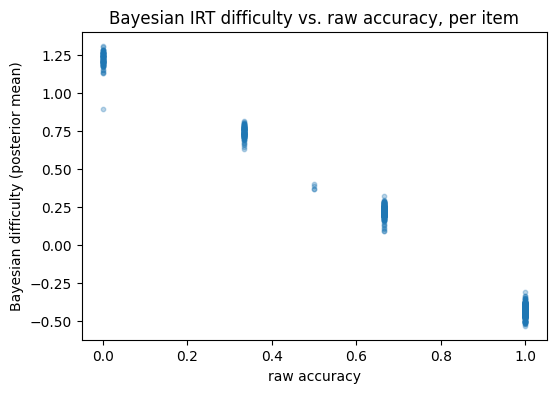

In [53]:
# Same plot as §7's "IRT difficulty vs. raw accuracy", but for the
# Bayesian posterior mean difficulty instead of the Rasch point estimate.
# item_accuracy was computed in the OTHER kernel, so load it from the cache
# §7 wrote out.
item_accuracy_loaded = json.load(open("irt_item_accuracy_cache.json"))

bayes_irt_vals, bayes_acc_vals = [], []
for item_id in item_ids_common:
    if item_id in item_accuracy_loaded:
        bayes_irt_vals.append(bayes.item_difficulty[item_id])
        bayes_acc_vals.append(item_accuracy_loaded[item_id])

corr_bayes = np.corrcoef(bayes_irt_vals, bayes_acc_vals)[0, 1]
print(f"correlation between Bayesian difficulty (posterior mean) and raw accuracy: {corr_bayes:.3f} "
      f"(expected strongly negative: harder=higher difficulty=lower accuracy)")

plt.figure(figsize=(6, 4))
plt.scatter(bayes_acc_vals, bayes_irt_vals, alpha=0.3, s=10)
plt.xlabel("raw accuracy")
plt.ylabel("Bayesian difficulty (posterior mean)")
plt.title("Bayesian IRT difficulty vs. raw accuracy, per item")
plt.show()

source     difficulty  n_items   mean_b   std_b
Onestop    Adv             324   -0.048   0.473
Onestop    Ele             324   -0.082   0.458
RACE       High            324    0.239   0.644
RACE       Middle          324   -0.109   0.511


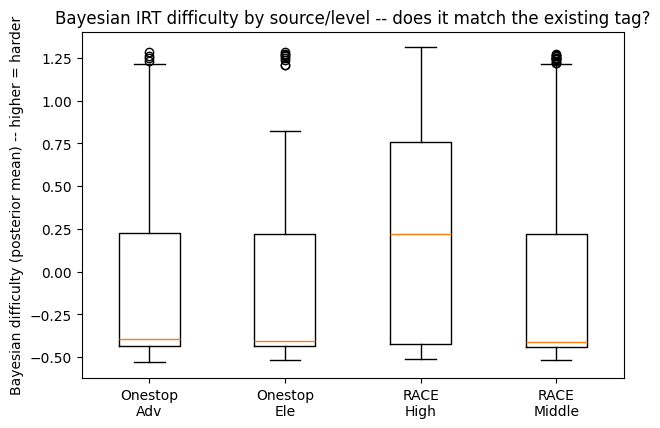

In [56]:
# Same source/level-vs-difficulty sanity check as §7, but for the Bayesian
# posterior mean difficulty. item_meta was computed in the OTHER kernel
# (needs HumanResponseBank/`datasets`), so load it from the cache §7 wrote.
from collections import defaultdict

item_meta_loaded = {k: tuple(v) for k, v in json.load(open("irt_item_meta_cache.json")).items()}

bayes_groups = defaultdict(list)
for item_id, b in bayes.item_difficulty.items():
    if item_id in item_meta_loaded:
        source, difficulty = item_meta_loaded[item_id]
        bayes_groups[(source, difficulty)].append(b)

group_order = sorted(bayes_groups.keys())
print(f"{'source':10s} {'difficulty':10s} {'n_items':>8s} {'mean_b':>8s} {'std_b':>7s}")
for key in group_order:
    vals = bayes_groups[key]
    print(f"{key[0]:10s} {key[1]:10s} {len(vals):8d} {np.mean(vals):8.3f} {np.std(vals):7.3f}")

plt.figure(figsize=(7, 4.5))
plt.boxplot([bayes_groups[k] for k in group_order], tick_labels=[f"{k[0]}\n{k[1]}" for k in group_order])
plt.ylabel("Bayesian difficulty (posterior mean) -- higher = harder")
plt.title("Bayesian IRT difficulty by source/level -- does it match the existing tag?")
plt.show()

In [57]:
# Find OneStopQA Adv/Ele item pairs with very similar IRT difficulty,
# for manual side-by-side inspection (uses Rasch item_difficulty, already
# available in this kernel -- same qualitative pattern as the Bayesian one).
adv_items = [(iid, item_difficulty[iid]) for iid, meta in item_meta.items()
             if meta == ("Onestop", "Adv") and iid in item_difficulty]
ele_items = [(iid, item_difficulty[iid]) for iid, meta in item_meta.items()
             if meta == ("Onestop", "Ele") and iid in item_difficulty]

pairs = []
for adv_id, adv_b in adv_items:
    closest_ele = min(ele_items, key=lambda x: abs(x[1] - adv_b))
    pairs.append((adv_id, adv_b, closest_ele[0], closest_ele[1], abs(adv_b - closest_ele[1])))
pairs.sort(key=lambda p: p[4])  # smallest difficulty gap first

rows_by_item = bank.rows_by_item()
for adv_id, adv_b, ele_id, ele_b, gap in pairs[:5]:
    print("=" * 80)
    print(f"Adv: {adv_id} (b={adv_b:.3f})   vs   Ele: {ele_id} (b={ele_b:.3f})   gap={gap:.3f}")
    for label, iid in [("ADV", adv_id), ("ELE", ele_id)]:
        r = rows_by_item[iid][0]
        print(f"\n--- {label} ({iid}) ---")
        print(f"Passage: {r['paragraph'][:500]}")
        print(f"Question: {r['question']}")
        print(f"Gold answer: {r['correct_answer_text']}")

Adv: os10_1_1_Adv (b=-1.097)   vs   Ele: os11_6_3_Ele (b=-1.097)   gap=0.000

--- ADV (os10_1_1_Adv) ---
Passage: Agios Efstratios is so remote, so forgotten by the banks, the government and most of the modern world that the mobile phone network can't process data and there isn't a single ATM or credit-card machine on the island. Before Greece was plunged into financial chaos, residents of this tranquil outpost in the northern Aegean managed quite well. They did their banking at the post office and the few dozen rooms to rent were booked out every summer with people who had heard - by word of mouth - of its
Question: What event dramatically reduced the quality of life for residents in Agios Efstratios?
Gold answer: The financial crisis that occurred in the country

--- ELE (os11_6_3_Ele) ---
Passage: Hannah, a 41-year-old lawyer, has made nearly 500 visits for the Mystery Dining Company in her spare time without receiving pay or travel expenses. She has enjoyed PS200 meals at Michelin-

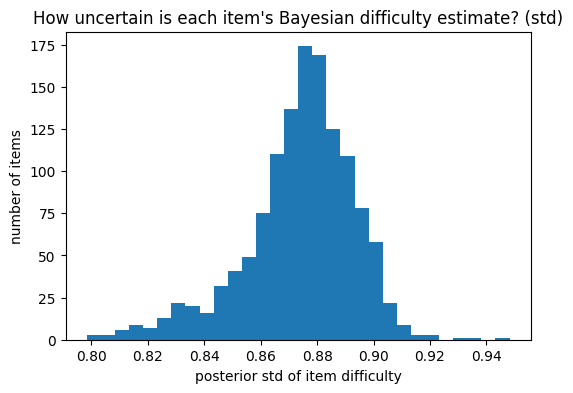

posterior std: mean=0.874  min=0.798  max=0.948

difficulty (posterior mean) itself: min=-0.531  max=+1.312  range=1.842  std=0.545
=> typical per-item uncertainty (std=0.874) is 1.6x the population std of the difficulty values, and 47.4% of the full difficulty range

items with std < 10% of difficulty range (< 0.184): 0/1296 (0.0%)
items with std < 20% of difficulty range (< 0.368): 0/1296 (0.0%)
items with std < 30% of difficulty range (< 0.553): 0/1296 (0.0%)
items with std < 40% of difficulty range (< 0.737): 0/1296 (0.0%)
items with std < 50% of difficulty range (< 0.921): 1292/1296 (99.7%)

even the single BEST-measured item has std=0.798 = 43.3% of the full range -- so no item clears even a 50% bar comfortably


In [58]:
# Same uncertainty story as the credible-interval-width plot above, but on
# the posterior std scale instead -- often more intuitive to read.
# (For a roughly-normal posterior, 95% HDI width ~= 3.92 * std, so this is
# largely the same information rescaled, not new information.)
stds = [bayes.item_difficulty_std[i] for i in item_ids_common]

plt.figure(figsize=(6, 4))
plt.hist(stds, bins=30)
plt.xlabel("posterior std of item difficulty")
plt.ylabel("number of items")
plt.title("How uncertain is each item's Bayesian difficulty estimate? (std)")
plt.show()

print(f"posterior std: mean={np.mean(stds):.3f}  min={np.min(stds):.3f}  max={np.max(stds):.3f}")

# Context: how big is that std relative to the actual spread of difficulty
# VALUES themselves (i.e. is 0.9 a lot or a little)?
diff_means = [bayes.item_difficulty[i] for i in item_ids_common]
diff_range = max(diff_means) - min(diff_means)
diff_std = np.std(diff_means)
print(f"\ndifficulty (posterior mean) itself: min={min(diff_means):+.3f}  max={max(diff_means):+.3f}  "
      f"range={diff_range:.3f}  std={diff_std:.3f}")
print(f"=> typical per-item uncertainty (std={np.mean(stds):.3f}) is "
      f"{np.mean(stds)/diff_std:.1f}x the population std of the difficulty values, "
      f"and {np.mean(stds)/diff_range:.1%} of the full difficulty range")

# How many items are actually well-measured -- i.e. their std is a SMALL
# fraction of the full difficulty range, not the majority of it?
stds_arr = np.array(stds)
n_items = len(stds_arr)
print()
for pct in (0.10, 0.20, 0.30, 0.40, 0.50):
    threshold = pct * diff_range
    count = int((stds_arr < threshold).sum())
    print(f"items with std < {pct:.0%} of difficulty range (< {threshold:.3f}): "
          f"{count}/{n_items} ({count/n_items:.1%})")

best_std = stds_arr.min()
print(f"\neven the single BEST-measured item has std={best_std:.3f} "
      f"= {best_std/diff_range:.1%} of the full range -- so no item clears even a 50% bar comfortably")

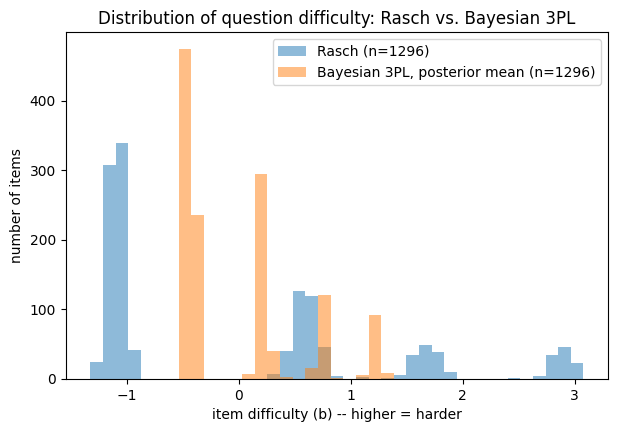

Rasch difficulty:    mean=-0.028  std=1.315
Bayesian difficulty: mean=+0.000  std=0.545
correlation between the two: 0.999


In [59]:
# Distribution of question difficulty -- Bayesian posterior means vs. the
# Rasch (§7) point estimates, on the same axes for direct comparison.
# Rasch's item_difficulty was computed in the OTHER kernel, so we load it
# back from the cache §7 wrote out.
rasch_difficulty = json.load(open("irt_rasch_difficulty_cache.json"))
rasch_vals = [rasch_difficulty[i] for i in item_ids_common if i in rasch_difficulty]
bayes_vals_common = [bayes.item_difficulty[i] for i in item_ids_common if i in rasch_difficulty]

plt.figure(figsize=(7, 4.5))
bins = np.linspace(
    min(rasch_vals + bayes_vals_common), max(rasch_vals + bayes_vals_common), 40
)
plt.hist(rasch_vals, bins=bins, alpha=0.5, label=f"Rasch (n={len(rasch_vals)})")
plt.hist(bayes_vals_common, bins=bins, alpha=0.5, label=f"Bayesian 3PL, posterior mean (n={len(bayes_vals_common)})")
plt.xlabel("item difficulty (b) -- higher = harder")
plt.ylabel("number of items")
plt.title("Distribution of question difficulty: Rasch vs. Bayesian 3PL")
plt.legend()
plt.show()

print(f"Rasch difficulty:    mean={np.mean(rasch_vals):+.3f}  std={np.std(rasch_vals):.3f}")
print(f"Bayesian difficulty: mean={np.mean(bayes_vals_common):+.3f}  std={np.std(bayes_vals_common):.3f}")
print(f"correlation between the two: {np.corrcoef(rasch_vals, bayes_vals_common)[0, 1]:.3f}")

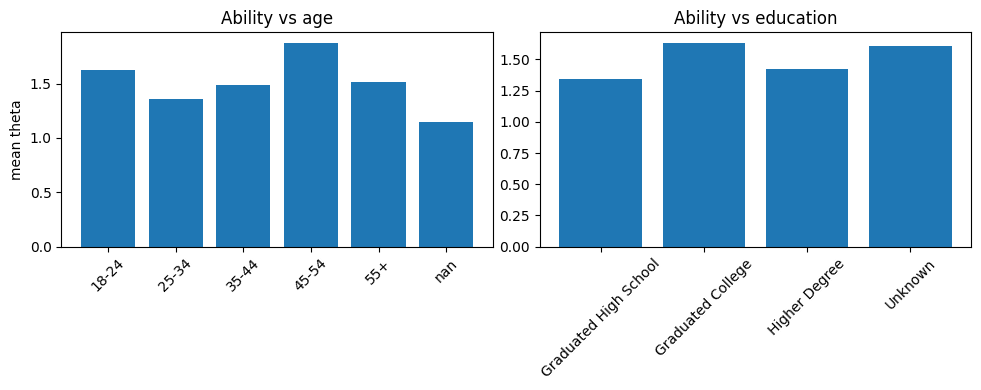

In [62]:
ability_rows = []
for bucket, theta in rasch.person_ability.items():
    age_group, education = bucket.split("|")
    ability_rows.append({"age_group": age_group, "education": education, "ability": theta})
ability_df = pd.DataFrame(ability_rows)

age_order = ["18-24", "25-34", "35-44", "45-54", "55+", "nan"]
edu_order = ["Graduated High School", "Graduated College", "Higher Degree", "Unknown"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

age_vals = ability_df.groupby("age_group")["ability"].mean().reindex(age_order)
axes[0].bar(age_vals.index, age_vals.values)
axes[0].set_title("Ability vs age")
axes[0].set_ylabel("mean theta")
axes[0].tick_params(axis="x", rotation=45)

edu_vals = ability_df.groupby("education")["ability"].mean().reindex(edu_order)
axes[1].bar(edu_vals.index, edu_vals.values)
axes[1].set_title("Ability vs education")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()